In [1]:
categories = [
    "alt.atheism",
    "talk.religion.misc",
    "comp.graphics",
    "sci.space",
]

In [2]:
from time import time

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [5]:
categories = [
    "alt.atheism",
    "talk.religion.misc",
    "comp.graphics",
    "sci.space",
]

train_data = fetch_20newsgroups(
    subset="train",
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=("headers", "footers", "quotes"),
)

test_data = fetch_20newsgroups(
    subset="test",
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=("headers", "footers", "quotes"),
)

print("Categories:", train_data.target_names)
print("Train samples:", len(train_data.data))
print("Test samples:", len(test_data.data))

Categories: ['alt.atheism', 'comp.graphics', 'sci.space', 'talk.religion.misc']
Train samples: 2034
Test samples: 1353


In [6]:
text_clf = Pipeline(
    [
        ("tfidf", TfidfVectorizer(stop_words="english", max_df=0.5)),
        ("clf", LogisticRegression(max_iter=1000)),
    ]
)

In [7]:
t0 = time()
text_clf.fit(train_data.data, train_data.target)
print(f"Training done in {time() - t0:.3f}s")

Training done in 1.030s


In [8]:
t0 = time()
y_pred = text_clf.predict(test_data.data)
print(f"Prediction done in {time() - t0:.3f}s")

accuracy = accuracy_score(test_data.target, y_pred)
print("Accuracy:", accuracy)
print(
    classification_report(
        test_data.target,
        y_pred,
        target_names=train_data.target_names,
    )
)

Prediction done in 0.151s
Accuracy: 0.7487065779748706
                    precision    recall  f1-score   support

       alt.atheism       0.65      0.60      0.63       319
     comp.graphics       0.88      0.90      0.89       389
         sci.space       0.72      0.90      0.80       394
talk.religion.misc       0.69      0.46      0.56       251

          accuracy                           0.75      1353
         macro avg       0.74      0.72      0.72      1353
      weighted avg       0.75      0.75      0.74      1353



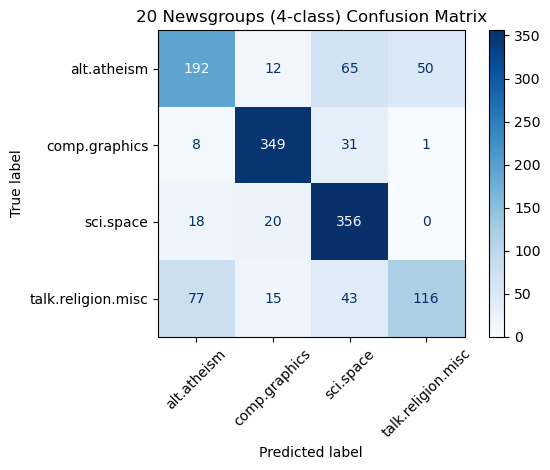

In [9]:
ConfusionMatrixDisplay.from_predictions(
    test_data.target,
    y_pred,
    display_labels=train_data.target_names,
    xticks_rotation=45,
    cmap=plt.cm.Blues,
)
plt.title("20 Newsgroups (4-class) Confusion Matrix")
plt.tight_layout()
plt.show()